<a href="https://colab.research.google.com/github/sarthakshukla74/PREDICTIVE-ANALYSIS-DIABETES/blob/main/Predictive_Analysis_for_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [ ]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


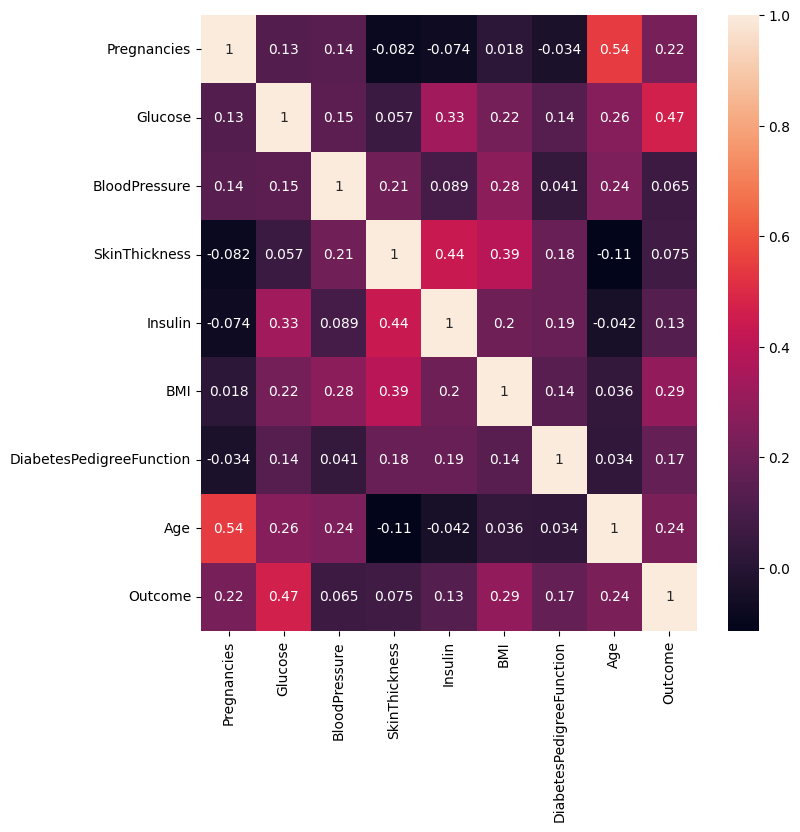

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

/tmp/ipython-input-3529679327.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col] ,bins=30 ,kde=True , ax=axis)
/tmp/ipython-input-3529679327.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col] ,bins=30 ,kde=True , ax=axis)
/tmp/ipython-input-3529679327.py:4: UserWarning: 

`dist

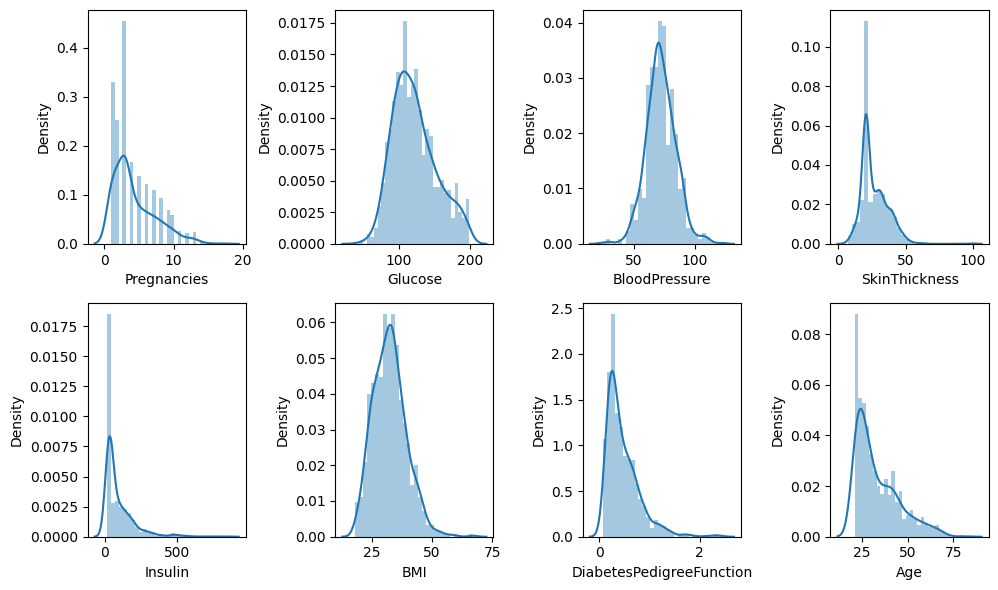

In [ ]:
columns = df.columns
fig ,ax=plt.subplots(2,4,figsize=(10,6))
for col , axis in zip(columns,ax.flatten()) :
    sns.distplot(df[col] ,bins=30 ,kde=True , ax=axis)
plt.tight_layout()

It is a "Zero Problem" where our reading may go wrong if we directly go for outliers removal before treating the zeros which are logically incorrect

Pregnancies , Insulin , DiabetesPedigreeFunction , Age :- Right Skewed , Therefore go for median.

Glucose , BloodPressure , SkinThickness , BMI :- Normally distributed, Therefore go for mean

In [ ]:
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].median())
df['BloodPressure']=df['BloodPressure'].replace(0,df['BloodPressure'].mean())
df['Glucose']=df['Glucose'].replace(0,df['Glucose'].mean())
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].mean())
df['Age']=df['Age'].replace(0,df['Age'].median())
df['Pregnancies']=df['Pregnancies'].replace(0,df['Pregnancies'].median())
df['BMI']=df['BMI'].replace(0,df['BMI'].mean())
df['DiabetesPedigreeFunction']=df['DiabetesPedigreeFunction'].replace(0,df['DiabetesPedigreeFunction'].median())

<Axes: >

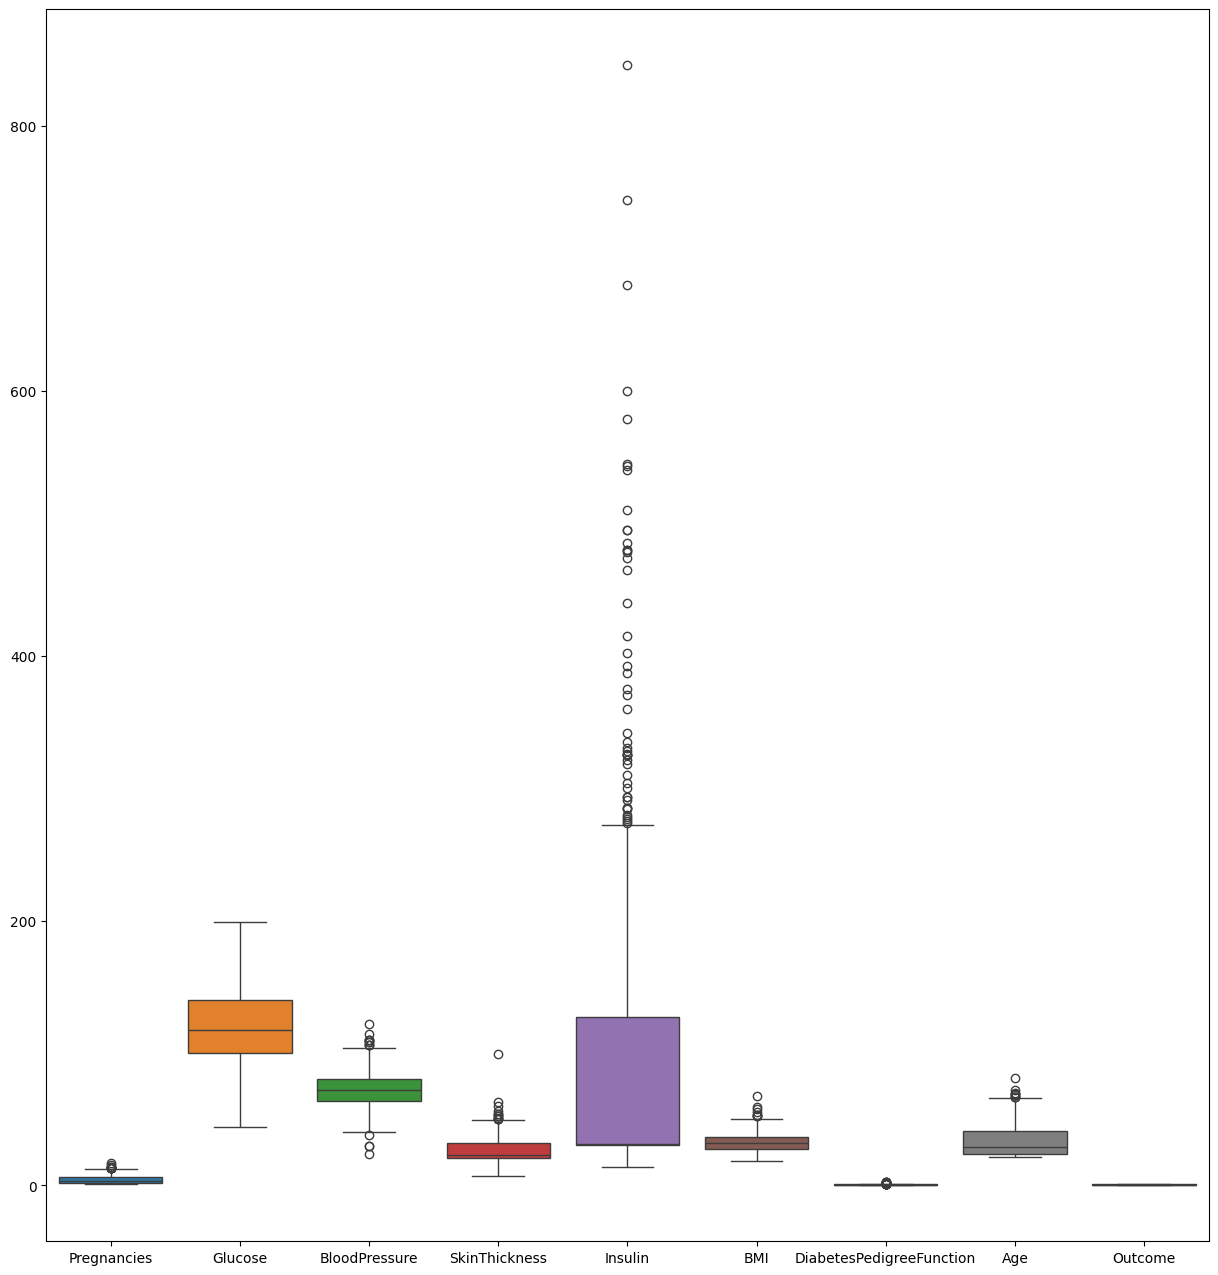

In [ ]:
fig,ax=plt.subplots(figsize=(15,16))
sns.boxplot(data=df,ax=ax)

**OUTLIER DETECTION AND HANDLING**

In [ ]:
# Separate features (x) and target (y) AFTER imputation
x = df.drop(columns='Outcome', axis=1)
y = df['Outcome']

In [ ]:
x.shape

(768, 8)

In [ ]:
columns_1=['Pregnancies' , 'Insulin' , 'BMI','DiabetesPedigreeFunction','Age']
columns_2=['Glucose' , 'BloodPressure' , 'SkinThickness']

In [ ]:
def iqr(cols,x):
 for col in cols:
  Q1=x[col].quantile(0.25)
  Q3=x[col].quantile(0.75)
  IQR=Q3-Q1
  lower_whisker =Q1-1.5*IQR
  upper_whisker =Q3+1.5*IQR
  x[col] = np.where(x[col]>upper_whisker , upper_whisker , x[col])
  x[col] = np.where(x[col]<lower_whisker , lower_whisker , x[col])


In [ ]:
def z_score(x, cols):
  for col in cols:
    mean = x[col].mean()
    deviation = x[col].std()
    feature=col+'_z_score'
    x[feature]=(x[col]-mean)/deviation
    upper_bound = mean + 3*deviation
    lower_bound = mean - 3*deviation

    x[col] = np.where(x[feature] >3  , upper_bound , x[col])
    x[col] = np.where(x[feature] <-3 , lower_bound , x[col])
    del(x[feature])

In [ ]:
iqr(columns_1, x)

In [ ]:
z_score(x, columns_2)

In [ ]:
x.shape

(768, 8)

**STANDARDIZATION**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
# Standardize the outlier-handled data
x_scaled = sc.fit_transform(x)

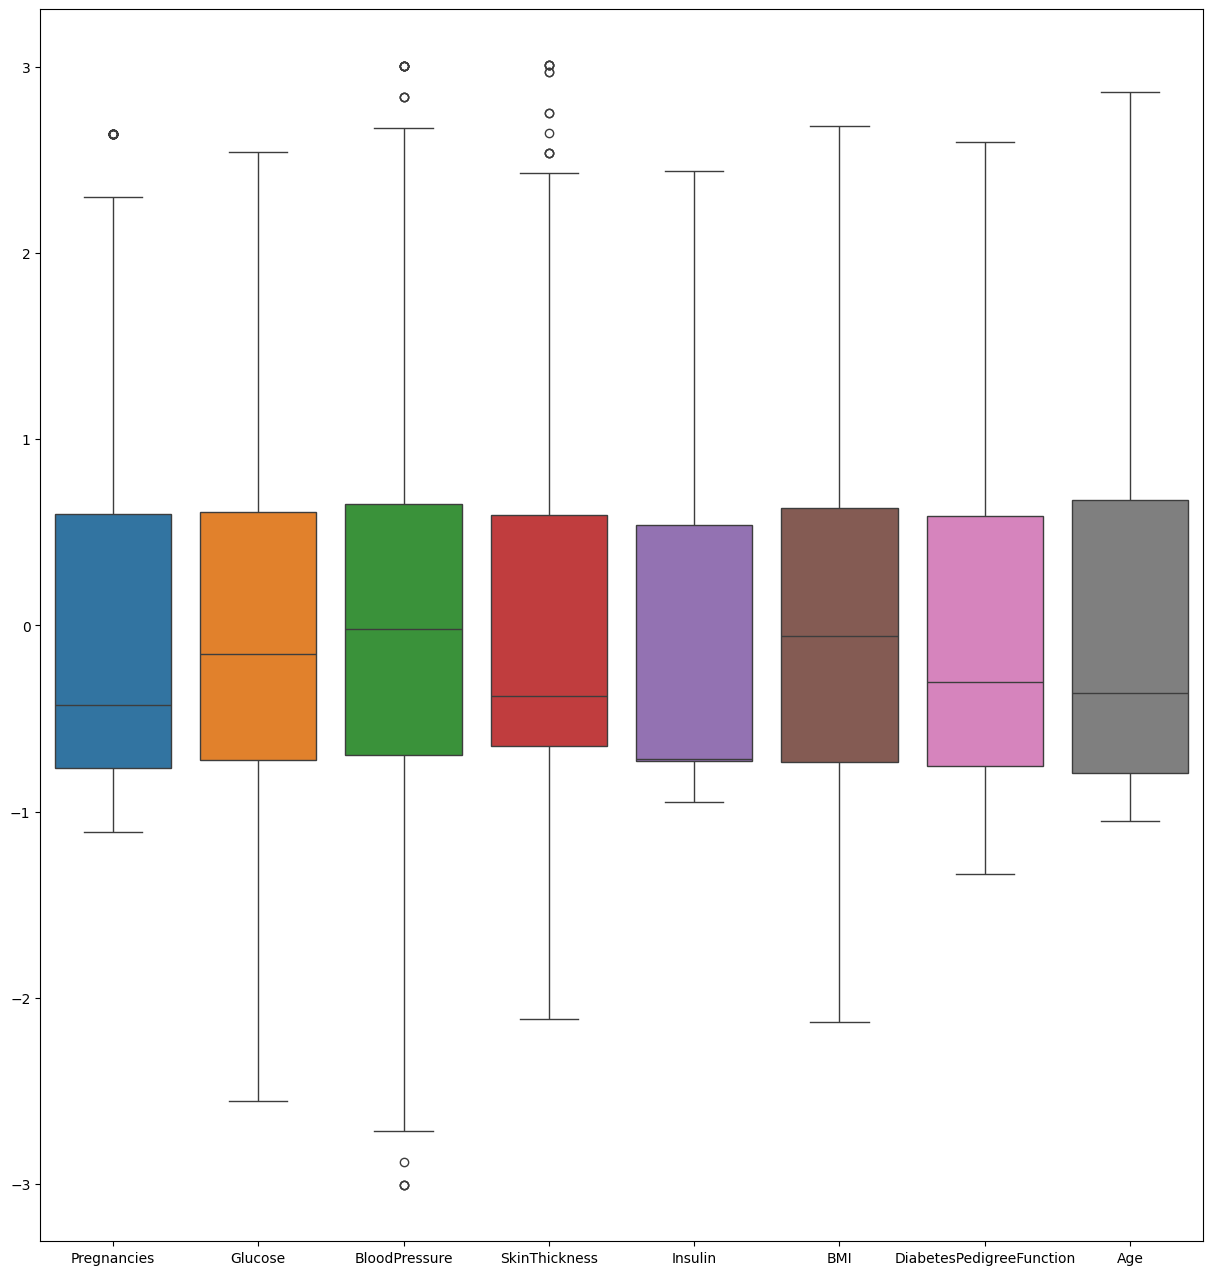

In [ ]:
# Plot boxplot of the standardized data
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

fig, ax = plt.subplots(figsize=(15,16))
sns.boxplot(data=x_scaled, ax=ax)
plt.show()

In [ ]:
x_scaled.shape

(768, 8)

In [ ]:
x_scaled.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

In [ ]:
q = x_scaled['Insulin'].quantile(.95)
mask = x_scaled['Insulin'] < q
dataNew = x_scaled[mask]
y_filtered = y[mask]

<Axes: >

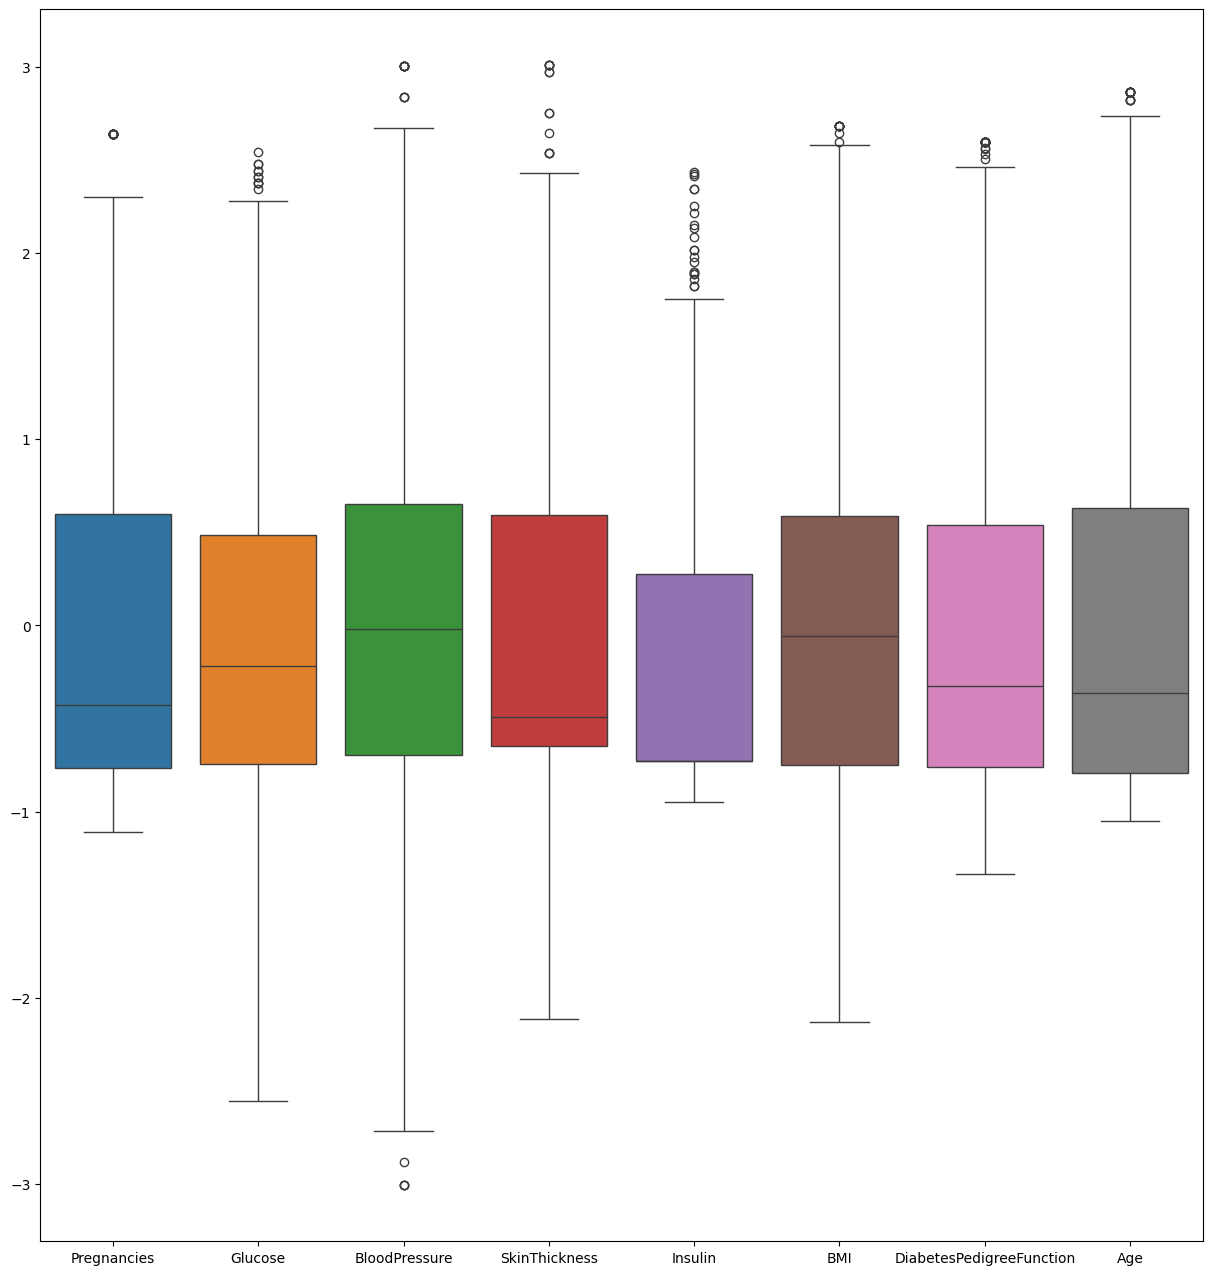

In [ ]:
fig,ax=plt.subplots(figsize=(15,16))
sns.boxplot(data=dataNew,ax=ax)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    dataNew, y_filtered, test_size=0.33, random_state=42
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Train shape: (481, 8)
Test shape: (238, 8)
y_train shape: (481,)
y_test shape: (238,)


In [ ]:
y_train.value_counts()

,count
Outcome,
0,313
1,168


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Check resampled class distribution
print("\nResampled class distribution:")
print(pd.Series(y_train_resampled).value_counts())


Resampled class distribution:
Outcome
1    313
0    313
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(x_train_resampled,y_train_resampled)

LogisticRegression()

In [ ]:
y_pred=logreg.predict(x_test)
print(y_pred)

[1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0
 0 0 1 0 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1
 0 0 0 0 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0
 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1
 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1
 0 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0
 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.7184873949579832


In [ ]:
from sklearn.metrics import classification_report
target_names=["Non_diabetic","Diabetic"]
print(classification_report(y_test,y_pred,target_names=target_names))

              precision    recall  f1-score   support

Non_diabetic       0.83      0.75      0.79       165
    Diabetic       0.53      0.66      0.59        73

    accuracy                           0.72       238
   macro avg       0.68      0.70      0.69       238
weighted avg       0.74      0.72      0.73       238

